Hands-On Lab: Engineering Features & Tuning 

● Step 1: Create at least two new engineered features for a provided dataset and justify each in Markdown.   
● Step 2: Define a hyperparameter grid for a model from Week 3 (e.g. random forest).    
● Step 3: Run GridSearchCV with 5-fold cross-validation and report the best parameters and score.           
● Step 4: Compare the tuned model's cross-validated score against the untuned baseline from Week 3.         
● Step 5: Document which engineered feature and which hyperparameter mattered most.         

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier , RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


cleaning the dataset ++ Small EDA:

In [4]:
print (df.isna().sum(),"\n")
print("duplicates: ",df.duplicated().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64 

duplicates:  3854


In [5]:
df.drop_duplicates(inplace=True)
print("duplicates: ",df.duplicated().sum())

df = df.reset_index(drop=True)

duplicates:  0


In [6]:
print(df.shape)
print(list(df.columns))

df.describe()

(96146, 9)
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
print(df['gender'].value_counts().to_frame(),"\n")
print(df['hypertension'].value_counts().to_frame(),"\n")
print(df['heart_disease'].value_counts().to_frame(),"\n")
print(df['diabetes'].value_counts().to_frame(),"\n")

        count
gender       
Female  56161
Male    39967
Other      18 

              count
hypertension       
0             88685
1              7461 

               count
heart_disease       
0              92223
1               3923 

          count
diabetes       
0         87664
1          8482 



Text(0.5, 1.0, 'Age-diabetes distribution')

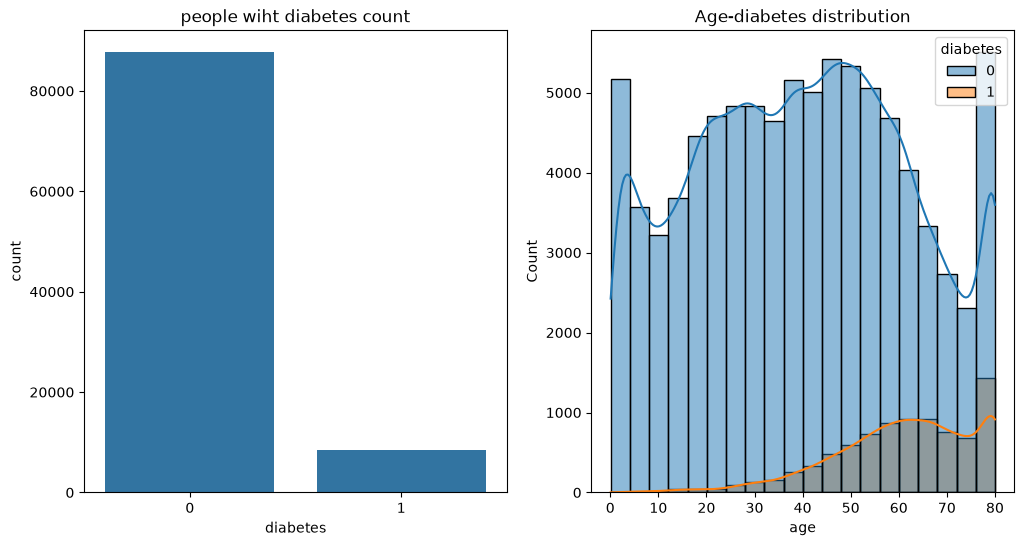

In [8]:
fig, axes = plt.subplots(1 , 2 , figsize=(12,6))
ax1 =sns.countplot(x= 'diabetes',data = df, ax= axes[0])
ax1.set_title('people wiht diabetes count')
ax2 =sns.histplot(x='age', hue='diabetes', data=df, ax=axes[1], bins=20, kde=True)
ax2.set_title('Age-diabetes distribution')


Creating Features:

 BMI_category feature:      
 since we have the BMI we can split it into categories for easier comprehension.        


In [9]:
bmi_label = ["underweight" , "normal" , "overweight" , "obese"]
bins = [0, 18.5 , 25 , 30, 100] # number of bins must be bigger than the number of labels by atleast one
df['BMI_category'] = pd.cut(df['bmi'], bins=bins, labels=bmi_label, include_lowest=True, right=True )

df['BMI_category']

0         overweight
1         overweight
2         overweight
3             normal
4             normal
            ...     
96141         normal
96142    underweight
96143     overweight
96144          obese
96145         normal
Name: BMI_category, Length: 96146, dtype: category
Categories (4, str): ['underweight' < 'normal' < 'overweight' < 'obese']

critical glycimic flag:     
checks HbA1c_level(simply it's blood sugar average over 3 monthes) and blood glucuse level, if any is higher than standerd it raises a flag.

In [10]:
# Flags 1 if HbA1c is >= 6.5 OR blood glucose is >= 126. Otherwise, 0.
df['critical_blood_sugar'] = ((df['HbA1c_level'] >= 6.5) | (df['blood_glucose_level'] >= 126)).astype(int)

# View the distribution of the new feature
print(df['critical_blood_sugar'].value_counts())

critical_blood_sugar
1    73782
0    22364
Name: count, dtype: int64


Model Training:

In [11]:
diabetes = df.drop(columns = ['diabetes'])

X = pd.get_dummies(diabetes, drop_first= True) # one hot encoding (converts categorical columns in diabetes into numerical columns)

y= df['diabetes'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)



Defining a hyperparameter grid & running GridSearchCV:

In [12]:
grid_param = {
    "n_estimators" : [50, 100, 150, 200],
    "max_depth" : [5, 7, 9]    
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), grid_param , cv=5, scoring="f1") # 5 fold cross validation

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information 

Printing the best hyper parameters:

In [13]:
print(grid.best_params_)     # the winning combination
print(grid.best_score_)      # its cross-validated score (training set f1)

best_model = grid.best_estimator_

print (best_model)

{'max_depth': 5, 'n_estimators': 50}
0.8008996288330424
RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)


Tunded vs Untuned model:

In [14]:
tuned_prediction = grid.predict(X_test) 
tuned_f1 = f1_score(y_test, tuned_prediction) #(testing set f1)

RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)
prediction =RF.predict(X_test)

untuned_f1 = f1_score(y_test, prediction)

print(f"Tuned f1: {tuned_f1}")
print(f"Untuned f1: {untuned_f1}")

Tuned f1: 0.8031988873435327
Untuned f1: 0.7952861952861953


The tuned differs slightly (better) from the untuned in this case.   
that is due to sklearn defualt trying to select the best hyperparameters.   
but i think in other cases of bigger more complex data it would have a greater effect.  

Which features mattered most:

In [23]:
importances = best_model.feature_importances_ # Extract feature importances from the tuned model

feature_names = X_train.columns # feature names (columns names)

# Create a DataFrame and sort it
feature_imp_dataframe = pd.DataFrame({'Features':feature_names, 'importance': importances})
feature_imp_dataframe = feature_imp_dataframe.sort_values(by= 'importance' , ascending= False)

print(f"top 5 importances {feature_imp_dataframe.head(5)}")

top 5 importances               Features  importance
4          HbA1c_level    0.477897
5  blood_glucose_level    0.398711
0                  age    0.039931
1         hypertension    0.019096
3                  bmi    0.018326


The engineered features didnt appear although thet were used in testing is due to not deleting the columns that were used to make them.     
sklearn divids importance if 2 features share the same value.       
that is why they didnt float to top 5.  

which hyperparameters mattered most:

In [32]:
## we want to compare the mean of (mean_test_score) of max depth and n_estimators (the ones we customized)

results_df = pd.DataFrame(grid.cv_results_) # put all of them in a dataframe

results_df # inspect the dataframe

print("Mean F1 Score by Max Depth ")
print(results_df.groupby('param_max_depth')['mean_test_score'].mean(),"\n")

print("Mean F1 score by N-Esimators ")
print(results_df.groupby('param_n_estimators')['mean_test_score'].mean())

Mean F1 Score by Max Depth 
param_max_depth
5    0.8009
7    0.8009
9    0.8009
Name: mean_test_score, dtype: float64 

Mean F1 score by N-Esimators 
param_n_estimators
50     0.8009
100    0.8009
150    0.8009
200    0.8009
Name: mean_test_score, dtype: float64


It gave an interesting result that suggests that both  hyperparameters had the same effect on performance (or possibly neither had any effect),   
 so changing either within the tested range did not change the Avg F1 score of 0.8009 .

Bar plot of most important features:

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_19532\3596803910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_dataframe.head(5) , x = 'Features', y = 'importance', palette='viridis')


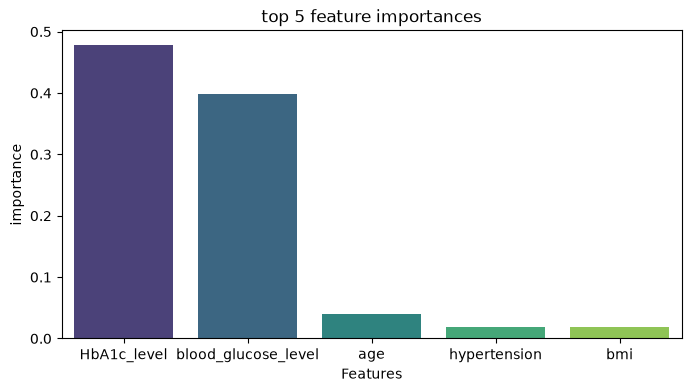

In [24]:
plt.figure(figsize=(8,4))
sns.barplot(data=feature_imp_dataframe.head(5) , x = 'Features', y = 'importance', palette='viridis')
plt.title('top 5 feature importances')
plt.show()